### Learning Goal
- **What concept is this notebook teaching?** Linear Regression and the concept of minimizing error (MSE).
- **Why does it matter?** It forms the foundation of all predictive modeling and neural networks.

In [2]:
import pandas as pd

df_math = pd.read_csv('./data/student-mat.csv', sep=';')
df_por = pd.read_csv('./data/student-por.csv', sep=';')
print(df_math)
print(df_por)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

In [3]:
import numpy as np

for df in [df_math, df_por]:
    print(df.info())
    print(df.isnull().sum())
    print(df.describe())
    print(df[df.duplicated(keep=False)])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### Visualization Interpretation
- **What pattern is visible?** A line of best fit cutting through a scatter plot.
- **Why does it happen?** The algorithm minimized the vertical distance between the points and the line.

                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.163658 -0.163438    0.070641  -0.004140  0.243665   
Medu       -0.163658  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu       -0.163438  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime  0.070641 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime  -0.004140  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures    0.243665 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel      0.053940 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime    0.016434  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout       0.126964  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc        0.131125  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc        0.117276 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health     -0.062187 -0.046878  0.014742    0.007501  -0.075616  0.065827   

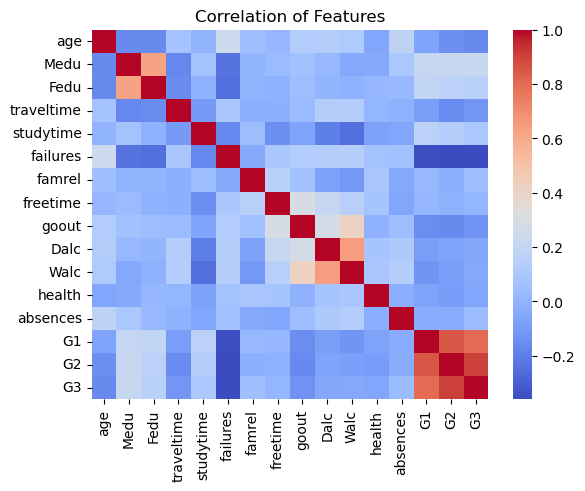

                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.107832 -0.121050    0.034490  -0.008415  0.319968   
Medu       -0.107832  1.000000  0.647477   -0.265079   0.097006 -0.172210   
Fedu       -0.121050  0.647477  1.000000   -0.208288   0.050400 -0.165915   
traveltime  0.034490 -0.265079 -0.208288    1.000000  -0.063154  0.097730   
studytime  -0.008415  0.097006  0.050400   -0.063154   1.000000 -0.147441   
failures    0.319968 -0.172210 -0.165915    0.097730  -0.147441  1.000000   
famrel     -0.020559  0.024421  0.020256   -0.009521  -0.004127 -0.062645   
freetime   -0.004910 -0.019686  0.006841    0.000937  -0.068829  0.108995   
goout       0.112805  0.009536  0.027690    0.057454  -0.075442  0.045078   
Dalc        0.134768 -0.007018  0.000061    0.092824  -0.137585  0.105949   
Walc        0.086357 -0.019766  0.038445    0.057007  -0.214925  0.082266   
health     -0.008750  0.004614  0.044910   -0.048261  -0.056433  0.035588   

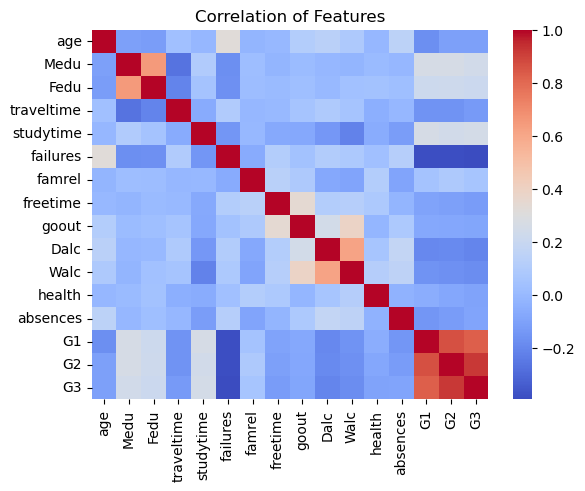

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

for df in [df_math, df_por]:
    corr = df.corr(numeric_only=True)
    print(corr)

    sns.heatmap(corr, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation of Features')
    plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [ ]:
# for df in [df_math, df_por]:
#     for i in df.columns:
#         sns.boxplot(df[i])
#         plt.show()

X_mat = df_math.drop(columns='G3').select_dtypes(include='number')
y_mat = df_math['G3']

X_por = df_por.drop(columns='G3').select_dtypes(include='number')
y_por = df_por['G3']

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

In [6]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_mat_train, X_mat_test, y_mat_train, y_mat_test = train_test_split(X_mat, y_mat, train_size=0.80, random_state=42)

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_por_train, X_por_test, y_por_train, y_por_test = train_test_split(X_por, y_por, train_size=0.80, random_state=42)

### Experiment
- **What are we changing?** We are fitting a straight line to scattered data points.
- **What do we expect to happen?** The line should pass through the center of mass of the points.

### Observation
- **What actually happened?** The model found the optimal coefficients to minimize the sum of squared residuals.

In [7]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_mat_train_scaled = scaler.fit_transform(X_mat_train)
X_mat_test_scaled = scaler.transform(X_mat_test)

X_por_train_scaled = scaler.fit_transform(X_por_train)
X_por_test_scaled = scaler.transform(X_por_test)

In [8]:
from sklearn.linear_model import LinearRegression

# Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
model_mat = LinearRegression()
# Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
model_por = LinearRegression()

model_mat.fit(X_mat_train_scaled, y_mat_train)
model_por.fit(X_por_train_scaled, y_por_train)

y_mat_pred = model_mat.predict(X_mat_test_scaled)
y_por_pred = model_por.predict(X_por_test_scaled)

for model in [model_mat, model_por]:
    print(model.coef_)
    print(model.intercept_)

[-0.25111864  0.10160354 -0.20279652  0.0901017  -0.055147   -0.30570936
  0.29581777  0.01082176  0.15383309 -0.09470161  0.07993395  0.08320977
  0.37725073  0.51627755  3.66573623]
10.325949367088608
[ 0.02472787 -0.07499641  0.0293886   0.04713187  0.08233975 -0.09466885
 -0.06031141 -0.08188013  0.03128011 -0.09296083  0.02085852 -0.03920569
  0.12206373  0.50311119  2.50513576]
11.79383429672447


In [9]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

predictions = {
    'Math': {
        'actual': y_mat_test, 
        'predicted': y_mat_pred
    },
    'Portuguese': {
        'actual': y_por_test, 
        'predicted': y_por_pred
    }
}


for subject, data in predictions.items():
    y_test = data['actual']
    y_pred = data['predicted']
    
    # Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
    mae = mean_absolute_error(y_test, y_pred)
    # Heavily penalize massive prediction errors by squaring the residuals before averaging.
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")

MAE: 1.3482
MSE: 4.5038
RMSE: 2.1222
R2: 0.7804
MAE: 0.7348
MSE: 1.3606
RMSE: 1.1664
R2: 0.8605


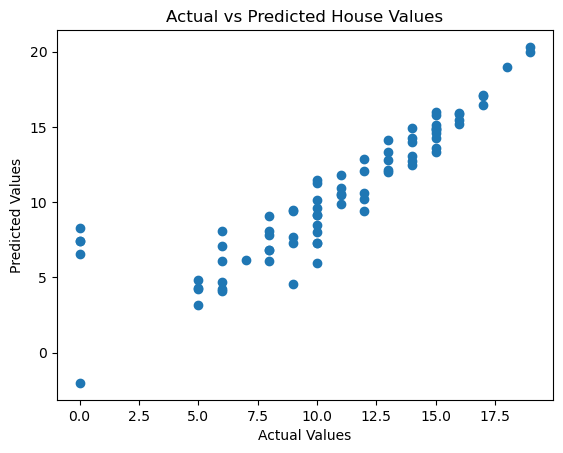

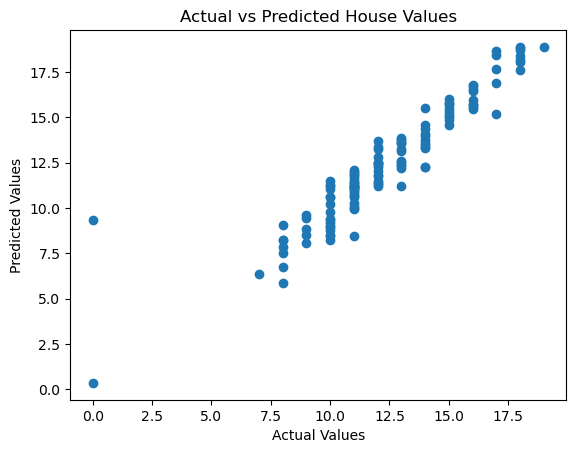

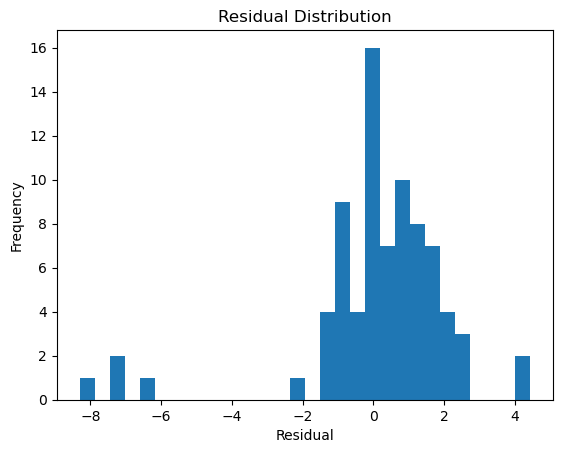

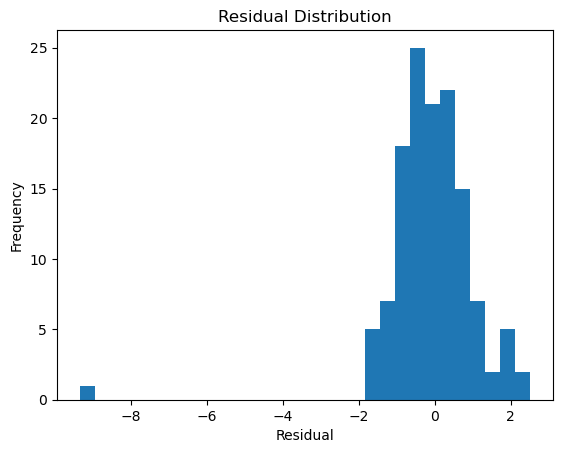

In [10]:
plt.scatter(y_mat_test, y_mat_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

plt.scatter(y_por_test, y_por_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

residuals_mat = y_mat_test - y_mat_pred
residuals_por = y_por_test - y_por_pred

for residuals in [residuals_mat, residuals_por]:
    plt.hist(residuals, bins=30)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution")

    plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [11]:
from sklearn.model_selection import cross_val_score

for subject, data in {
    'Math': {'X': X_mat, 'y': y_mat},
    'Portuguese': {'X': X_por, 'y': y_por}
}.items():
    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(model, data['X'], data['y'], cv=5)

    print("CV R² Scores:", scores)
    print("Mean CV R²:", scores.mean())
    print("Std CV R²:", scores.std())

CV R² Scores: [0.83444375 0.90674852 0.80291399 0.77727569 0.71589892]
Mean CV R²: 0.8074561716146811
Std CV R²: 0.06308965584706037
CV R² Scores: [0.76701405 0.75861392 0.83506822 0.8906312  0.8069576 ]
Mean CV R²: 0.8116569986823171
Std CV R²: 0.04819471782665862


In [12]:
for subject, data in {
    'Math': {'model': model_mat, 'X': X_mat},
    'Portuguese': {'model': model_por, 'X': X_por}
}.items():
    feature_importance = pd.Series(
        model.coef_,
        index=X.columns
    ).sort_values(ascending=False)

    print(feature_importance)

NameError: name 'X' is not defined

### Comparison
- **Simple vs Complex:** A simple line fails to capture curved data, leading to high bias.

### Common Mistakes
- **Beginner Mistake:** Using Linear Regression on data that has massive outliers without removing them first.

### Practical Takeaway
- **Industry Application:** Used constantly in finance for baseline forecasting.

### Key Insight
- **Memorable lesson:** Linear models are fast and interpretable, but assume the world operates in straight lines.